In [0]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, count, when

# This one's from my team. 

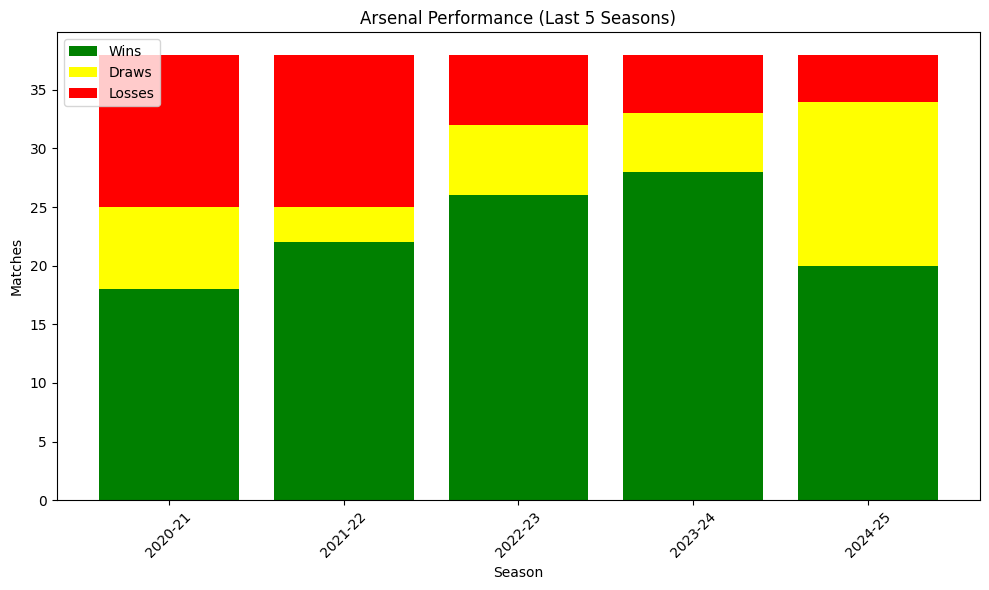


Arsenal total wins: 114
Arsenal total draws: 35
Arsenal total losses: 41


In [0]:
# Arsenal performance over 5 seasons
arsenal_home = matches.filter(col("HomeTeam") == "Arsenal")
arsenal_away = matches.filter(col("AwayTeam") == "Arsenal")

arsenal_results = arsenal_home.select("season", "FTR").unionAll(
    arsenal_away.select("season", 
        when(col("FTR") == "H", "A")
        .when(col("FTR") == "A", "H")
        .otherwise("D").alias("FTR"))
)

arsenal_stats = arsenal_results.groupBy("season", "FTR").count().toPandas()

# Get wins by season
arsenal_wins = arsenal_stats[arsenal_stats["FTR"] == "H"].pivot_table(
    values="count", index="season", aggfunc="sum"
).fillna(0)

# Plot
import matplotlib.pyplot as plt

seasons = arsenal_stats["season"].unique()
wins = []
draws = []
losses = []

for season in sorted(seasons):
    season_data = arsenal_stats[arsenal_stats["season"] == season]
    wins.append(season_data[season_data["FTR"] == "H"]["count"].sum() if len(season_data[season_data["FTR"] == "H"]) > 0 else 0)
    draws.append(season_data[season_data["FTR"] == "D"]["count"].sum() if len(season_data[season_data["FTR"] == "D"]) > 0 else 0)
    losses.append(season_data[season_data["FTR"] == "A"]["count"].sum() if len(season_data[season_data["FTR"] == "A"]) > 0 else 0)

plt.figure(figsize=(10, 6))
plt.bar(sorted(seasons), wins, label="Wins", color="green")
plt.bar(sorted(seasons), draws, bottom=wins, label="Draws", color="yellow")
plt.bar(sorted(seasons), losses, bottom=[w+d for w,d in zip(wins, draws)], label="Losses", color="red")
plt.xlabel("Season")
plt.ylabel("Matches")
plt.title("Arsenal Performance (Last 5 Seasons)")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print(f"\nArsenal total wins: {sum(wins)}")
print(f"Arsenal total draws: {sum(draws)}")
print(f"Arsenal total losses: {sum(losses)}")

# DataSets 1 

In [0]:
# Load datasets
PROJECT = "premier_league"
SCHEMA_BRONZE = f"workspace.{PROJECT}_bronze"

standings_2023 = spark.read.table(f"{SCHEMA_BRONZE}.pl_standings_2023")
standings_2024 = spark.read.table(f"{SCHEMA_BRONZE}.pl_standings_2024")
matches = spark.read.table(f"{SCHEMA_BRONZE}.pl_matches_historical")

print("Loaded datasets")

Loaded datasets


In [0]:
# Dataset 1: Standings - Basic info
print("DATASET 1: STANDINGS")
print(f"2023-24 rows: {standings_2023.count()}")
print(f"2023-24 columns: {len(standings_2023.columns)}")
print(f"2024-25 rows: {standings_2024.count()}")
print(f"2024-25 columns: {len(standings_2024.columns)}")

DATASET 1: STANDINGS
2023-24 rows: 20
2023-24 columns: 15
2024-25 rows: 20
2024-25 columns: 15


In [0]:
# Column types
standings_2024.printSchema()

root
 |-- draw: long (nullable = true)
 |-- goal_difference: long (nullable = true)
 |-- goals_against: long (nullable = true)
 |-- goals_for: long (nullable = true)
 |-- ingestion_date: string (nullable = true)
 |-- lost: long (nullable = true)
 |-- played_games: long (nullable = true)
 |-- points: long (nullable = true)
 |-- position: long (nullable = true)
 |-- season: string (nullable = true)
 |-- team_id: long (nullable = true)
 |-- team_name: string (nullable = true)
 |-- team_short_name: string (nullable = true)
 |-- team_tla: string (nullable = true)
 |-- won: long (nullable = true)



In [0]:
# Sample data
standings_2024.orderBy("position").show(10, truncate=False)

+----+---------------+-------------+---------+-------------------+----+------------+------+--------+-------+-------+-------------------------+---------------+--------+---+
|draw|goal_difference|goals_against|goals_for|ingestion_date     |lost|played_games|points|position|season |team_id|team_name                |team_short_name|team_tla|won|
+----+---------------+-------------+---------+-------------------+----+------------+------+--------+-------+-------+-------------------------+---------------+--------+---+
|9   |45             |41           |86       |2025-10-27 03:49:26|4   |38          |84    |1       |2024-25|64     |Liverpool FC             |Liverpool      |LIV     |25 |
|14  |35             |34           |69       |2025-10-27 03:49:26|4   |38          |74    |2       |2024-25|57     |Arsenal FC               |Arsenal        |ARS     |20 |
|8   |28             |44           |72       |2025-10-27 03:49:26|9   |38          |71    |3       |2024-25|65     |Manchester City FC      

In [0]:
# Missing values check
null_counts = standings_2024.select([
    count(when(col(c).isNull(), c)).alias(c) for c in standings_2024.columns
])
null_counts.toPandas().T

,0
draw,0
goal_difference,0
goals_against,0
goals_for,0
ingestion_date,0
lost,0
played_games,0
points,0
position,0
season,0


In [0]:
# Duplicates check
total = standings_2024.count()
distinct = standings_2024.distinct().count()
print(f"Total rows: {total}")
print(f"Distinct rows: {distinct}")
print(f"Duplicates: {total - distinct}")

Total rows: 20
Distinct rows: 20
Duplicates: 0


In [0]:
# Numeric statistics
standings_2024.select("played_games", "won", "draw", "lost", "points", 
                      "goals_for", "goals_against").describe().show()

+-------+------------+------------------+------------------+-----------------+------------------+------------------+------------------+
|summary|played_games|               won|              draw|             lost|            points|         goals_for|     goals_against|
+-------+------------+------------------+------------------+-----------------+------------------+------------------+------------------+
|  count|          20|                20|                20|               20|                20|                20|                20|
|   mean|        38.0|             14.35|               9.3|            14.35|             52.35|             55.75|             55.75|
| stddev|         0.0|6.0024117959717715|2.8672378052018894|6.960603422117942|18.576371522645868|14.707230588351683|14.421748926717008|
|    min|          38|                 2|                 5|                4|                12|                26|                34|
|    max|          38|                25|       

# Dataset 2


In [0]:
# Dataset 2: Matches - Basic info
print("DATASET 2: HISTORICAL MATCHES")
print(f"Total rows: {matches.count()}")
print(f"Total columns: {len(matches.columns)}")

DATASET 2: HISTORICAL MATCHES
Total rows: 1900
Total columns: 135


In [0]:
# Matches by season
matches.groupBy("season").count().orderBy("season").show()

+-------+-----+
| season|count|
+-------+-----+
|2020-21|  380|
|2021-22|  380|
|2022-23|  380|
|2023-24|  380|
|2024-25|  380|
+-------+-----+



In [0]:
# Sample matches
matches.select("Date", "HomeTeam", "AwayTeam", "FTHG", "FTAG", "FTR", "season").show(15)

+----------+----------------+--------------+----+----+---+-------+
|      Date|        HomeTeam|      AwayTeam|FTHG|FTAG|FTR| season|
+----------+----------------+--------------+----+----+---+-------+
|12/09/2020|          Fulham|       Arsenal|   0|   3|  A|2020-21|
|12/09/2020|  Crystal Palace|   Southampton|   1|   0|  H|2020-21|
|12/09/2020|       Liverpool|         Leeds|   4|   3|  H|2020-21|
|12/09/2020|        West Ham|     Newcastle|   0|   2|  A|2020-21|
|13/09/2020|       West Brom|     Leicester|   0|   3|  A|2020-21|
|13/09/2020|       Tottenham|       Everton|   0|   1|  A|2020-21|
|14/09/2020|        Brighton|       Chelsea|   1|   3|  A|2020-21|
|14/09/2020|Sheffield United|        Wolves|   0|   2|  A|2020-21|
|19/09/2020|         Everton|     West Brom|   5|   2|  H|2020-21|
|19/09/2020|           Leeds|        Fulham|   4|   3|  H|2020-21|
|19/09/2020|      Man United|Crystal Palace|   1|   3|  A|2020-21|
|19/09/2020|         Arsenal|      West Ham|   2|   1|  H|2020

In [0]:
# Missing values in key columns
key_cols = ["Date", "HomeTeam", "AwayTeam", "FTHG", "FTAG", "FTR"]
for c in key_cols:
    null_count = matches.filter(col(c).isNull()).count()
    print(f"{c}: {null_count} missing")

Date: 0 missing
HomeTeam: 0 missing
AwayTeam: 0 missing
FTHG: 0 missing
FTAG: 0 missing
FTR: 0 missing


In [0]:
# Duplicates
total_m = matches.count()
distinct_m = matches.select("Date", "HomeTeam", "AwayTeam").distinct().count()
print(f"Total: {total_m}, Distinct: {distinct_m}, Duplicates: {total_m - distinct_m}")

Total: 1900, Distinct: 1900, Duplicates: 0


In [0]:
# Goal statistics
matches.select("FTHG", "FTAG").describe().show()

+-------+------------------+------------------+
|summary|              FTHG|              FTAG|
+-------+------------------+------------------+
|  count|              1900|              1900|
|   mean|1.5626315789473684|1.3531578947368421|
| stddev|1.3497306973226346|1.2361994477357545|
|    min|                 0|                 0|
|    max|                 9|                 8|
+-------+------------------+------------------+



In [0]:
# Result distribution
matches.groupBy("FTR").count().show()

+---+-----+
|FTR|count|
+---+-----+
|  H|  821|
|  A|  646|
|  D|  433|
+---+-----+



In [0]:
# Unique teams
print(f"Unique home teams: {matches.select('HomeTeam').distinct().count()}")
print(f"Unique away teams: {matches.select('AwayTeam').distinct().count()}")

Unique home teams: 27
Unique away teams: 27


In [0]:
# Sanity check - do results match scores
check = matches.withColumn("expected", 
    when(col("FTHG") > col("FTAG"), "H")
    .when(col("FTHG") < col("FTAG"), "A")
    .otherwise("D"))
mismatches = check.filter(col("FTR") != col("expected")).count()
print(f"Result mismatches: {mismatches}")

Result mismatches: 0


In [0]:
print("Analysis complete")
print("Transformation:")
print("- I will probably need to. feature engineer Using binary for representation Rather than Numbers and strings ")
print("- Convert dates to date type")
print("- Handle missing values in stats columns")

Analysis complete
Transformation:
- I will probably need to. feature engineer Using binary for representation Rather than Numbers and strings 
- Convert dates to date type
- Handle missing values in stats columns


# plot for all the teams and the data 

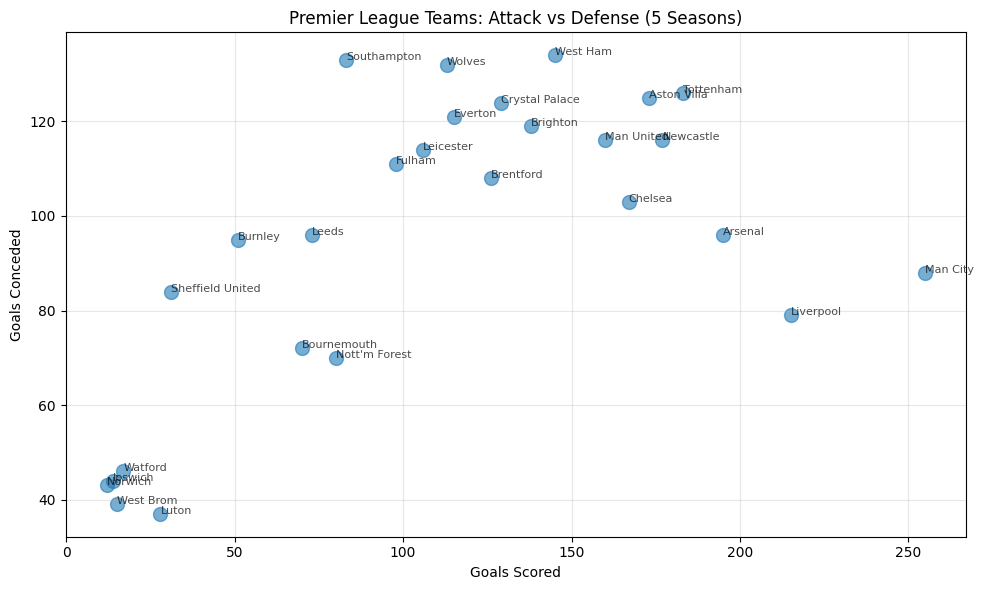

Top right = strong attack, weak defense
Bottom left = weak attack, strong defense


In [0]:
# Overall team performance - goals scored vs conceded
team_stats = matches.groupBy("HomeTeam").agg(
    {"FTHG": "sum", "FTAG": "sum"}
).toPandas()

team_stats.columns = ["Team", "Goals_For", "Goals_Against"]

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.scatter(team_stats["Goals_For"], team_stats["Goals_Against"], s=100, alpha=0.6)

for i, team in enumerate(team_stats["Team"]):
    plt.annotate(team, (team_stats["Goals_For"][i], team_stats["Goals_Against"][i]), 
                 fontsize=8, alpha=0.7)

plt.xlabel("Goals Scored")
plt.ylabel("Goals Conceded")
plt.title("Premier League Teams: Attack vs Defense (5 Seasons)")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("Top right = strong attack, weak defense")
print("Bottom left = weak attack, strong defense")